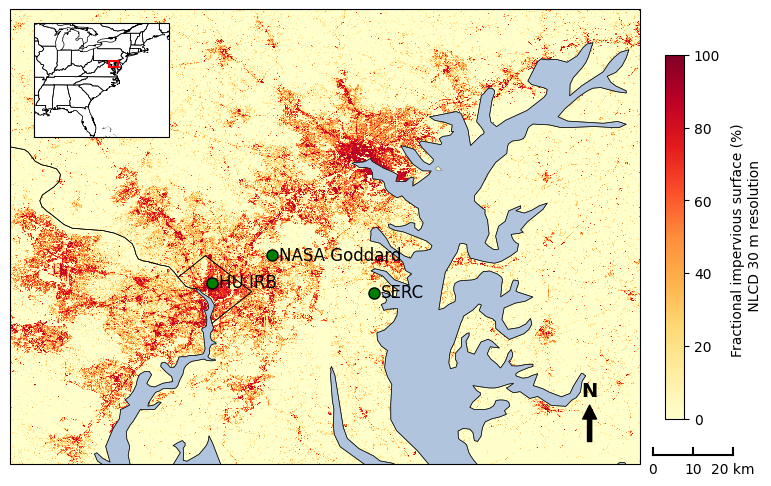

In [47]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import numpy as np
import rioxarray

main_extent = [-77.6, -75.8, 38.4, 39.7]
inset_extent = [-92.0, -66.0, 25.0, 47.0]

sites = {
    "NASA Goddard": (38.9977, -76.8525),
    "HU IRB":       (38.9193, -77.0215),
    "SERC":         (38.890131, -76.560014),
}

fig = plt.figure(figsize=(9, 12))
ax = fig.add_axes([0.1, 0.1, 0.7, 0.8], projection=ccrs.PlateCarree())
ax.set_extent(main_extent, crs=ccrs.PlateCarree())

tif_path = "/Users/ujjawal/Downloads/Ceilometer Script/data/Annual_NLCD_FctImp_2024_CU_C1V1_73500eef-4690-4280-b48a-9188b6681a2a.tiff"
raster = rioxarray.open_rasterio(tif_path)
raster = raster.rio.reproject("EPSG:4326")

min_lon, max_lon, min_lat, max_lat = main_extent
raster_clipped = raster.rio.clip_box(minx=min_lon, miny=min_lat, maxx=max_lon, maxy=max_lat)

lons = raster_clipped.x.values
lats = raster_clipped.y.values
lon_grid, lat_grid = np.meshgrid(lons, lats)
z = raster_clipped.squeeze().values

z = np.where((z < 0) | (z > 100), np.nan, z)

im = ax.pcolormesh(lon_grid, lat_grid, z, transform=ccrs.PlateCarree(), 
                   cmap='YlOrRd', vmin=0, vmax=100, shading='auto')

water_color = '#B0C4DE' 
ocean = cfeature.NaturalEarthFeature('physical', 'ocean', '10m', 
                                     facecolor=water_color, edgecolor='gray', linewidth=0.5)
lakes = cfeature.NaturalEarthFeature('physical', 'lakes', '10m', 
                                     facecolor=water_color, edgecolor='gray', linewidth=0.5)

ax.add_feature(ocean, zorder=2)
ax.add_feature(lakes, zorder=2)
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth=0.5, zorder=3, edgecolor='black', facecolor='none')

for site, (lat, lon) in sites.items():
    ax.plot(lon, lat, marker='o', color='green', markersize=8, 
            markeredgecolor='black', transform=ccrs.PlateCarree(), zorder=5)
    ax.text(lon + 0.02, lat, site, transform=ccrs.PlateCarree(),
            fontsize=12, ha='left', va='center',
            zorder=6)

inset_ax = ax.inset_axes([0.02, 0.72, 0.25, 0.25], projection=ccrs.PlateCarree())
inset_ax.set_extent(inset_extent, crs=ccrs.PlateCarree())

inset_ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black', linewidth=0.5)
inset_ax.add_feature(cfeature.OCEAN, facecolor='white')
inset_ax.add_feature(cfeature.STATES, linewidth=0.5)

rect = mpatches.Rectangle((main_extent[0], main_extent[2]), 
                          main_extent[1] - main_extent[0], 
                          main_extent[3] - main_extent[2],
                          linewidth=1.5, edgecolor='red', facecolor='none',
                          transform=ccrs.PlateCarree(), zorder=10)
inset_ax.add_patch(rect)

cbar_ax = ax.inset_axes([1.04, 0.1, 0.03, 0.8])
cbar = plt.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.set_label('Fractional impervious surface (%) \n NLCD 30 m resolution', fontsize=10, labelpad=8)
cbar.set_ticks([0, 20, 40, 60, 80, 100])

ax.text(0.92, 0.15, 'N', transform=ax.transAxes, fontsize=14, fontweight='bold', ha='center')
ax.annotate('', xy=(0.92, 0.13), xytext=(0.92, 0.05), xycoords='axes fraction',
            arrowprops=dict(facecolor='black', width=3, headwidth=10, headlength=10),
            ha='center', va='center')

# Shifted scale bar to the right
bar_x_start = 1.02
bar_y = 0.02
bar_width = 0.128

ax.plot([bar_x_start, bar_x_start + bar_width], [bar_y, bar_y], 
        color='black', linewidth=1.5, transform=ax.transAxes, clip_on=False)

tick_x = [bar_x_start, bar_x_start + bar_width / 2, bar_x_start + bar_width]
labels = ['0', '10', '20 km']
for x, label in zip(tick_x, labels):
    ax.plot([x, x], [bar_y, bar_y + 0.015], color='black', linewidth=1.5, 
            transform=ax.transAxes, clip_on=False)
    ax.text(x, bar_y - 0.015, label, transform=ax.transAxes, 
            ha='center', va='top', fontsize=10)

plt.savefig('../data/impervious_surface_map.png', dpi=300, bbox_inches='tight')
plt.show()

In [48]:
import os
import ssl
import requests
import datetime

# Fix SSL issues for secure downloads
if (not os.environ.get('PYTHONHTTPSVERIFY', '') and getattr(ssl, '_create_unverified_context', None)):
    ssl._create_default_https_context = ssl._create_unverified_context

# Mapping of custom site names to AERONET official site names
site_name_map = {
    "GSFC": "GSFC",
    "HU_IRB": "Howard_Univ-IRB",
    "SERC": "SERC"
}

# User-defined parameters
sites = ["GSFC", "HU_IRB", "SERC"]
levels = ["15", "20"]
products = ["directsun"]
start_year = 2020
end_year = 2025
avg = 10 

# Get current date
now = datetime.datetime.now()
current_year = now.year
current_month = now.month
current_day = now.day

# Loop through sites and years to download data
for aeronet_site in sites:
    site = site_name_map[aeronet_site]
    
    # --- UPDATED PATH ---
    # Goes up one level, into 'data', then organizes by site and 'Raw'
    save_dir = os.path.join("..", "data", aeronet_site, "Raw")
    os.makedirs(save_dir, exist_ok=True)

    for year in range(start_year, end_year + 1):
        month_start, day_start = "01", "01"

        if year == current_year:
            month_end = f"{current_month:02d}"
            day_end = f"{current_day:02d}"
        else:
            month_end, day_end = "12", "31"

        for level in levels:
            for product in products:
                url = (f"https://aeronet.gsfc.nasa.gov/cgi-bin/print_web_data_v3?site={site}"
                       f"&year={year}&month={month_start}&day={day_start}"
                       f"&year2={year}&month2={month_end}&day2={day_end}"
                       f"&AOD{level}=1&AVG={avg}&if_no_html=1")

                filename = f"{aeronet_site}_raw_{year}_AOD{level}_{product}.csv"
                filepath = os.path.join(save_dir, filename)

                print(f"\n🔹 Checking: {filename}")

                try:
                    response = requests.get(url)
                    response.raise_for_status()

                    if "No Data" in response.text or len(response.text.strip()) < 50:
                        print(f"No valid data found for {year} (AOD {level}). Skipping...")
                        continue

                    with open(filepath, "w") as file:
                        file.write(response.text)

                    print(f"✅ Data saved to: {filepath}")
                except Exception as e:
                    print(f"❌ Failed to download {filename}. Error: {e}")

print("\nAll downloads completed!")


🔹 Checking: GSFC_raw_2020_AOD15_directsun.csv
✅ Data saved to: ../data/GSFC/Raw/GSFC_raw_2020_AOD15_directsun.csv

🔹 Checking: GSFC_raw_2020_AOD20_directsun.csv
✅ Data saved to: ../data/GSFC/Raw/GSFC_raw_2020_AOD20_directsun.csv

🔹 Checking: GSFC_raw_2021_AOD15_directsun.csv
✅ Data saved to: ../data/GSFC/Raw/GSFC_raw_2021_AOD15_directsun.csv

🔹 Checking: GSFC_raw_2021_AOD20_directsun.csv
✅ Data saved to: ../data/GSFC/Raw/GSFC_raw_2021_AOD20_directsun.csv

🔹 Checking: GSFC_raw_2022_AOD15_directsun.csv
✅ Data saved to: ../data/GSFC/Raw/GSFC_raw_2022_AOD15_directsun.csv

🔹 Checking: GSFC_raw_2022_AOD20_directsun.csv
✅ Data saved to: ../data/GSFC/Raw/GSFC_raw_2022_AOD20_directsun.csv

🔹 Checking: GSFC_raw_2023_AOD15_directsun.csv
✅ Data saved to: ../data/GSFC/Raw/GSFC_raw_2023_AOD15_directsun.csv

🔹 Checking: GSFC_raw_2023_AOD20_directsun.csv
✅ Data saved to: ../data/GSFC/Raw/GSFC_raw_2023_AOD20_directsun.csv

🔹 Checking: GSFC_raw_2024_AOD15_directsun.csv
✅ Data saved to: ../data/GSFC/Raw

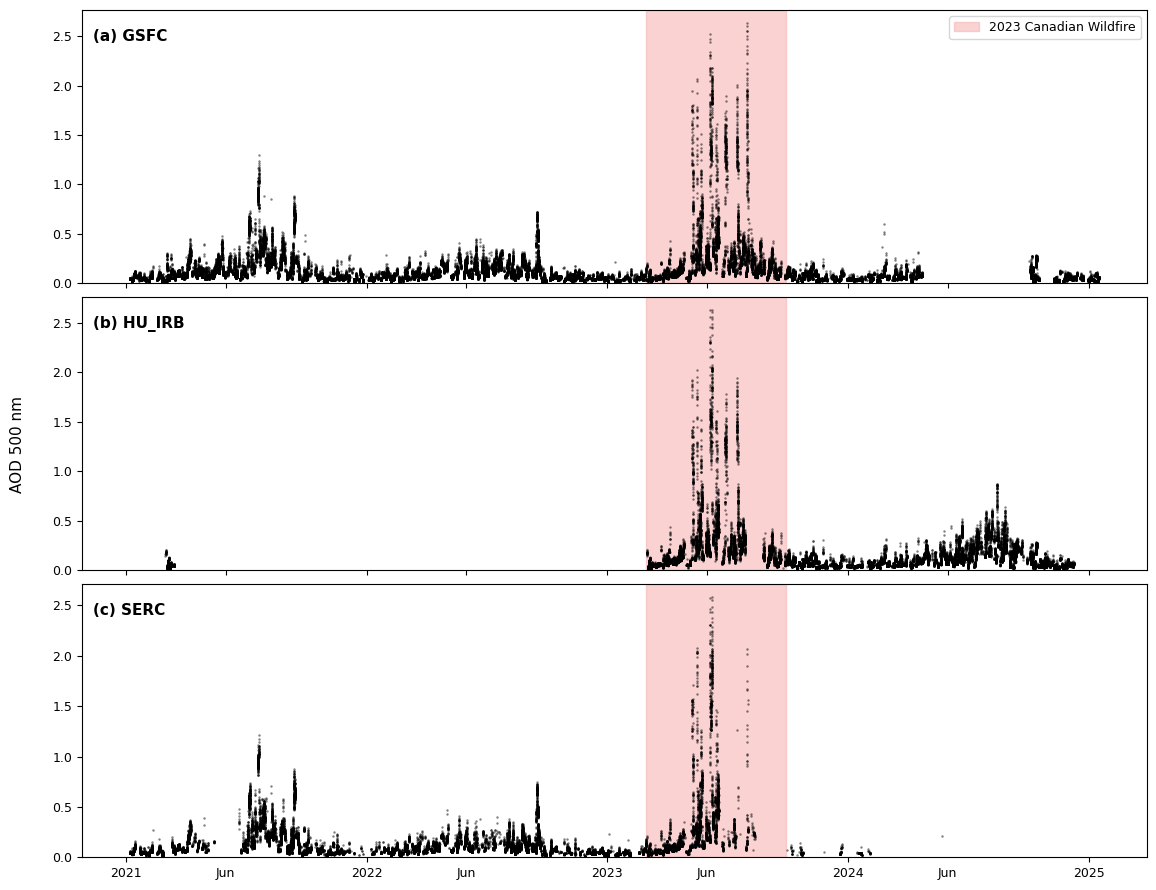

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sites  = ["GSFC", "HU_IRB", "SERC"]
labels = ["(a)", "(b)", "(c)"]

highlight_start = pd.Timestamp("2023-03-01")
highlight_end   = pd.Timestamp("2023-09-30")

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, sharey=False)

for ax, site, label in zip(axes, sites, labels):
    df = pd.read_csv(f"../data/{site}_AOD500_preprocessed.csv", parse_dates=["datetime"])
    df = df.dropna(subset=["AOD_500nm"]).sort_values("datetime")
    df = df[df["datetime"].dt.year.between(2021, 2025)]

    ax.axvspan(highlight_start, highlight_end,
               color="#f8b4b4", alpha=0.6, zorder=0, label="2023 Canadian Wildfire")

    ax.scatter(df["datetime"], df["AOD_500nm"],
               s=3, color="black", alpha=0.5, linewidths=0, zorder=2)

    ax.text(0.01, 0.93, f"{label} {site}", transform=ax.transAxes,
            fontsize=11, fontweight="bold", va="top")

    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=9)

    if ax == axes[0]:
        ax.legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.8)

# Shared Y-axis label
fig.text(0.04, 0.5, "AOD 500 nm", va="center", rotation="vertical", fontsize=11)

# X-axis formatting on bottom panel only
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 6]))

def custom_fmt(x, pos=None):
    dt = mdates.num2date(x)
    return str(dt.year) if dt.month == 1 else "Jun"

axes[-1].xaxis.set_major_formatter(plt.FuncFormatter(custom_fmt))

fig.canvas.draw()
for tick in axes[-1].xaxis.get_major_ticks():
    if tick.label1.get_text() == "Jun":
        tick.tick1line.set_visible(False)
        tick.tick2line.set_visible(False)

axes[-1].tick_params(axis="x", labelsize=9)

plt.tight_layout(h_pad=0.4)
plt.subplots_adjust(left=0.1)
plt.savefig("../data/AOD_time_series.png", dpi=300, bbox_inches="tight")
plt.show()

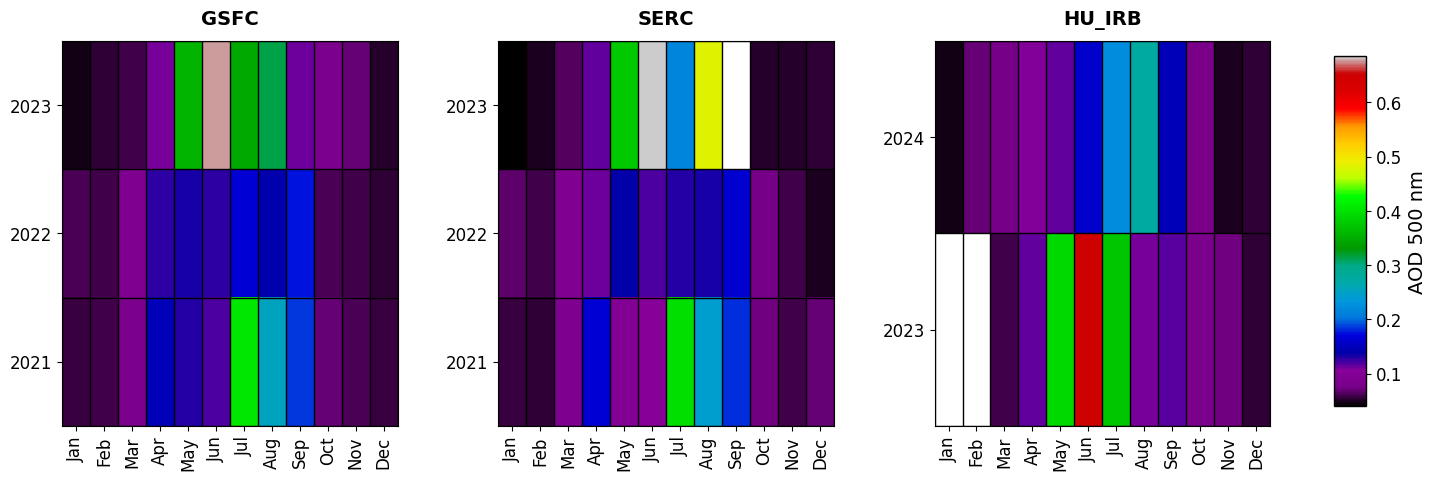

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

site_years = {
    "GSFC": [2021, 2022, 2023],
        "HU_IRB": [2023, 2024],
    "SERC": [2021, 2022, 2023]
}

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

pivots = {}
vmin_global = np.inf
vmax_global = -np.inf

for site, years in site_years.items():
    df = pd.read_csv(f"../data/{site}_AOD500_preprocessed.csv", parse_dates=["datetime"])
    df = df.dropna(subset=["AOD_500nm"])
    df["year"] = df["datetime"].dt.year
    df["month"] = df["datetime"].dt.month
    df = df[df["year"].isin(years)]
    
    years_desc = sorted(years, reverse=True)
    pivot = df.groupby(["year", "month"])["AOD_500nm"].mean().unstack(level=1)
    pivot = pivot.reindex(index=years_desc, columns=range(1, 13))
    pivots[site] = pivot
    
    vmin_global = min(vmin_global, pivot.min().min())
    vmax_global = max(vmax_global, pivot.max().max())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
norm = Normalize(vmin=vmin_global, vmax=vmax_global)

for ax, (site, years) in zip(axes, site_years.items()):
    years_desc = sorted(years, reverse=True)
    pivot = pivots[site]
    
    im = ax.imshow(pivot.values, aspect="auto", cmap="nipy_spectral", norm=norm)
    
    ax.set_xticks(np.arange(12))
    ax.set_xticklabels(months, rotation=90, fontsize=12)
    ax.set_yticks(np.arange(len(years_desc)))
    ax.set_yticklabels(years_desc, fontsize=12)
    
    ax.set_xticks(np.arange(-0.5, 12, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(years_desc), 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)
    
    ax.set_title(site, fontsize=14, fontweight="bold", pad=12)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("AOD 500 nm", fontsize=14)
cbar.ax.tick_params(labelsize=12)
cbar.outline.set_linewidth(1)

plt.subplots_adjust(right=0.88, wspace=0.3)
plt.savefig("../data/AOD_monthly_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()